# Weighted CGFS on a stratified sample vs the full dataset

Three seeds per dataset. For each seed: draw a **stratified sample** of the size
you set, run the usual pipeline on it (split → screen → z-score → similarity →
MI weights → weighted CGFS), fit a random forest on the top 5/10/15/20/25/30
features, and record F1. The result is plotted against the full-dataset numbers
you already have.

Everything downstream of the sampling step — `load_dataset`, `screen_columns`,
`zscore`, `rectified_cosine_matrix`, `mi_weights`, `cgfs` — is lifted verbatim
from the benchmark notebook, so the only difference between the two curves is how
many rows the pipeline saw.

**Two things to set before running.**

1. **`F1_AVERAGE`.** Your reference numbers are labelled "F1-score", which is
   ambiguous between support-weighted and macro. The notebook computes *both*
   every time and stores them; `F1_AVERAGE` only decides which one is compared
   and plotted. If the constants in `FULL_REFERENCE` came from the `F1(w)` column
   of the benchmark notebook, leave it as `"weighted"`; if from `Macro-F1`, switch
   it. Getting this wrong silently compares two different quantities.
2. **The budget list.** Your message reads "5, 10, 15, 20, 15, and 30" — 15
   twice and no 25. Since you gave six distinct reference values per dataset and
   the benchmark used 5–30 in steps of 5, this notebook assumes the fifth budget
   is **25**. Change `K_LIST` if that is wrong.

**What "stratified sample" means here.** The sample is drawn from the whole
dataset *before* the train/test split, so both splits shrink together — this
measures how the method behaves with less data overall, not how it behaves with a
smaller training set against a full test set. Class proportions are preserved,
except that every class is guaranteed at least `MIN_PER_CLASS` rows, since a
stratified 70/30 split needs two members of every class to be possible at all.
Rare attack classes are therefore slightly over-represented relative to their true
share; the run log reports which classes were boosted.

**Two seed dimensions.** `SAMPLE_SEEDS` chooses which rows get sampled;
`SEEDS` chooses the train/test split and the forest. The grid is every
combination, so `3 × 3 = 9` runs per dataset per budget, and the two sources of
spread are kept apart rather than pooled:

* **σ_sampling** — std across sample draws, after averaging over `SEEDS` within
  each draw. This is the number that answers "would a different 10% have given me
  a different answer?", and it is what the shaded band on the plot shows.
* **σ_split** — std across `SEEDS` within one draw, averaged over draws. Split and
  forest variance, the same component your full-dataset reference numbers carry,
  and therefore the only one that is like-for-like with them.
* **σ_total** — std over all nine runs, for reference.

Reporting a single pooled ± would hide which of the two dominates, and they mean
different things: σ_split large means the pipeline is unstable, σ_sampling large
means the sample size is too small to trust. Setting `SAMPLE_SEEDS` to a single
value reproduces the earlier behaviour, with σ_sampling undefined.

**Base sub-sampling.** `BASE_SAMPLE` applies a per-class fraction at load time,
before anything else, for datasets whose reference numbers were produced that way.
CICIoT2023 is configured with `frac = 1/7, random_state = 42`, reproducing the
`groupby('label').apply(lambda x: x.sample(...))` step behind its full-dataset
column. For that dataset, "full" therefore means the 1/7 subset, and the
experiment's own 10% is 10% *of that*, not of the raw capture.

## 1. Configuration

In [22]:
# ---------------------------------------------------------------- config ----
DATA_DIR = "."                   # the DatasetSpec paths below are relative to this
OUT_DIR  = "."

DATASETS_TO_RUN = ["rt-iot", "edge-iiot", "cic-iot"]
SEEDS   = [0, 1, 2, 3, 4]
K_LIST  = [5, 10, 15, 20, 25, 30]     # see note 2 in the header about the fifth budget

# --- the knob you asked for --------------------------------------------------
# int          -> that many rows
# float in (0,1] -> that fraction of the dataset
# None         -> the whole dataset (reproduces the full-sample run)
# dict         -> per dataset key, e.g. {"rt-iot": 20_000, "cic-iot": 0.05}
SAMPLE_SIZE   = {"rt-iot": 0.2, "edge-iiot": 0.2, "cic-iot": 0.2}
MIN_PER_CLASS = 2                # a stratified 70/30 split needs >= 2 rows per class

# Each of these draws its own stratified sample; every one is then run against
# every seed in SEEDS. Sampling and split/forest variance are reported separately
# (see the header). A single-element list reproduces the one-sample behaviour.
SAMPLE_SEEDS = [40, 41, 42]

# Per-class fraction applied at load time, before everything else, for datasets
# whose reference numbers were produced on a sub-sampled file. This reproduces
#     df.groupby(target, group_keys=False).apply(lambda x: x.sample(frac=f, random_state=rs))
# so "full dataset" for CICIoT2023 means this 1/7 subset, and SAMPLE_SIZE is then
# a fraction of it.
BASE_SAMPLE = {
    "cic-iot": {"frac": 1 / 7, "random_state": 42},
}

F1_AVERAGE = "weighted"          # "weighted" or "macro" -- must match FULL_REFERENCE

TEST_SIZE = 0.30
N_JOBS    = -1
CLF_N_ESTIMATORS = 100

MI_BINS           = 32
NEAR_CONST_THRESH = 0.995
SCREEN            = True
DROP_LEAKY        = True

# Run the full-dataset pipeline here instead of using the pasted constants below.
# Slow (that is the whole point of sampling), but it removes any doubt that the
# two curves were produced by identical code.
RUN_FULL_TOO = False

# --- full-dataset reference: mean, std at k = 5, 10, 15, 20, 25, 30 ----------
# Taken from the random-forest F1 column of the full benchmark run.
FULL_REFERENCE = {
    "rt-iot": {
        5:  (0.9671, 0.0120), 10: (0.9799, 0.0021), 15: (0.9794, 0.0005),
        20: (0.9798, 0.0004), 25: (0.9982, 0.0002), 30: (0.9982, 0.0002),
    },
    "edge-iiot": {
        5:  (0.6763, 0.0015), 10: (0.9525, 0.0007), 15: (0.9696, 0.0004),
        20: (0.9698, 0.0004), 25: (0.9740, 0.0010), 30: (0.9754, 0.0008),
    },
    "cic-iot": {
        5:  (0.9953, 0.0003), 10: (0.9955, 0.0002), 15: (0.9948, 0.0002),
        20: (0.9952, 0.0001), 25: (0.9952, 0.0001), 30: (0.9948, 0.0001),
    },
}

VERBOSE = True

## 2. Imports

In [23]:
import heapq, time, warnings, os
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")

try:
    import faiss
    HAVE_FAISS = True
except ImportError:
    HAVE_FAISS = False

print(f"numpy {np.__version__} | pandas {pd.__version__} | matplotlib {matplotlib.__version__}")
print(f"faiss: {'yes' if HAVE_FAISS else 'NO  -> exact NumPy/BLAS fallback (identical similarities)'}")

numpy 1.26.4 | pandas 2.1.4 | matplotlib 3.8.2
faiss: yes


## 3. Dataset specs and preprocessing

Verbatim from the benchmark notebook.

In [24]:
@dataclass(frozen=True)
class DatasetSpec:
    name: str
    path: str
    target: str
    drop: list
    # Columns that identify hosts/sessions or are raw payload/timestamps.
    leaky: list = field(default_factory=list)


DATASETS = {
    "rt-iot": DatasetSpec(
        name="RT-IoT2022",
        path="../RT_IOT2022.csv",
        target="Attack_type",
        drop=["Unnamed: 0", "Attack_type", "Attack_Label"],
        leaky=[],
    ),
    "edge-iiot": DatasetSpec(
        name="Edge-IIoTset",
        path="../ML-EdgeIIoT-dataset.csv",
        target="Attack_type",
        drop=["Attack_label", "Attack_type"],
        leaky=[
            "frame.time", "ip.src_host", "ip.dst_host",
            "arp.src.proto_ipv4", "arp.dst.proto_ipv4",
            "http.request.full_uri", "http.file_data", "http.request.uri.query",
            "tcp.payload", "tcp.options", "mqtt.msg", "dns.qry.name",
        ],
    ),
        "cic-iot": DatasetSpec(
        name="CICIoT2023",
        path="../CICIoT2023.csv",
        target="label",
        drop=['label', 'Binary Label'],
        leaky=[
        ],
    ),
}


def apply_base_sample(df, col, frac, random_state):
    """Per-class fraction, equivalent to

        df.groupby(col, group_keys=False).apply(lambda x: x.sample(frac, random_state))

    written without .apply because pandas 3.0 stops passing the grouping column
    through to the function, which would drop the label column outright. Group
    order and the rows chosen within each group are identical: groupby sorts its
    keys, and each group gets a fresh RandomState(random_state), exactly as the
    .apply form does.
    """
    parts = [g.sample(frac=frac, random_state=random_state)
             for _, g in df.groupby(col, sort=True)]
    out = pd.concat(parts)
    print(f"  base sample: {len(df):,} -> {len(out):,} rows "
          f"(per-class frac={frac:.4g}, random_state={random_state})")
    return out


def load_dataset(spec: DatasetSpec, drop_leaky: bool, base_sample=None):
    """Read the CSV, drop target/leaky columns, integer-encode the rest."""
    path = os.path.join(DATA_DIR, spec.path)
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Could not find '{path}'. Set DATA_DIR (and DATASET_KEY) in the config cell.")
    df = pd.read_csv(path, low_memory=False)
    if base_sample:
        df = apply_base_sample(df, spec.target, base_sample["frac"],
                               base_sample["random_state"])
    
    y = df[spec.target].values
    X = df.drop([c for c in spec.drop if c in df.columns], axis=1)
    if drop_leaky:
        dropped_leaky = [c for c in spec.leaky if c in X.columns]
        X = X.drop(dropped_leaky, axis=1)
    else:
        dropped_leaky = []

    # Test numeric-ness rather than `dtype == 'object'`: on pandas >= 3.0 text
    # columns carry the dedicated 'str' dtype, so the older check silently skips
    # them and the string values reach the similarity computation unencoded.
    encoded = []
    for col in X.columns:
        if not pd.api.types.is_numeric_dtype(X[col]):
            X[col] = LabelEncoder().fit_transform(X[col].astype(str))
            encoded.append(col)

    X = X.replace([np.inf, -np.inf], np.nan)
    n_filled = int(X.isna().to_numpy().sum())
    X = X.fillna(0)

    print(f"{spec.name}: {X.shape[0]:,} rows x {X.shape[1]} columns "
          f"({'leaky columns dropped: ' + str(dropped_leaky) if drop_leaky else 'LEAKY COLUMNS KEPT'})")
    print(f"  label-encoded columns : {encoded if encoded else 'none'}")
    print(f"  non-finite/missing cells filled with 0 : {n_filled:,}")
    return X.values.astype(np.float64), y, list(X.columns)

## 4. Screening and standardisation

In [25]:
def screen_columns(Xtr: np.ndarray, cols: list, enabled: bool,
                   near_const_thresh):
    """Indices of columns kept after constant / near-constant screening."""
    if not enabled:
        return list(range(Xtr.shape[1])), list(cols)
    keep = []
    n = len(Xtr)
    for j in range(Xtr.shape[1]):
        col = Xtr[:, j]
        if len(np.unique(col)) <= 1:
            continue
        if near_const_thresh is not None:
            _, counts = np.unique(col, return_counts=True)
            if counts.max() / n >= near_const_thresh:
                continue
        keep.append(j)
    return keep, [cols[j] for j in keep]


def zscore(Xtr: np.ndarray, Xte: np.ndarray):
    """Standardize with training statistics only."""
    mu = Xtr.mean(axis=0)
    sd = Xtr.std(axis=0)
    sd[sd == 0] = 1.0
    return (Xtr - mu) / sd, (Xte - mu) / sd

## 5. Rectified cosine similarity and MI relevance weights

In [26]:
def _l2_normalize_rows(M):
    """faiss.normalize_L2 semantics: zero rows are left as zero rows."""
    norms = np.linalg.norm(M, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return M / norms


def _exact_ip_search(feat, m):
    """Exact drop-in for faiss IndexFlatIP(...).search(feat, m)."""
    S = feat @ feat.T
    I = np.argsort(-S, axis=1, kind="stable")[:, :m]
    D = np.take_along_axis(S, I, axis=1)
    return D.astype(np.float32), I.astype(np.int64)


def rectified_cosine_matrix(Z: np.ndarray) -> np.ndarray:
    """s(f_i,f_j) = |cos(f_i,f_j)| for every pair, via an exact flat index."""
    d = Z.shape[1]
    feat = Z.T.astype(np.float32).copy()           # (d, n): one row per feature
    if HAVE_FAISS:
        faiss.normalize_L2(feat)
        index = faiss.IndexFlatIP(feat.shape[1])
        index.add(feat)
        D, I = index.search(feat, d)
    else:
        feat = _l2_normalize_rows(feat)
        D, I = _exact_ip_search(feat, d)
    sim = np.empty((d, d), dtype=np.float64)
    np.put_along_axis(sim, I, D.astype(np.float64), axis=1)   # back to column order
    sim = np.abs(sim)
    np.fill_diagonal(sim, 1.0)                     # s(f_i,f_i) = 1 exactly
    return sim


def _bin_column(col: np.ndarray, bins: int) -> np.ndarray:
    """Quantile-bin a column; low-cardinality columns are used as-is (exact)."""
    uniq = np.unique(col)
    if len(uniq) <= bins:
        return np.searchsorted(uniq, col)
    edges = np.quantile(col, np.linspace(0.0, 1.0, bins + 1)[1:-1])
    return np.digitize(col, np.unique(edges))


def _mi_from_codes(a: np.ndarray, b: np.ndarray) -> float:
    """Plug-in mutual information between two integer-coded variables, in nats."""
    joint = np.histogram2d(a, b, bins=(a.max() + 1, b.max() + 1))[0]
    P = joint / joint.sum()
    px = P.sum(axis=1, keepdims=True)
    py = P.sum(axis=0, keepdims=True)
    nz = P > 0
    return float((P[nz] * np.log(P[nz] / (px @ py)[nz])).sum())


def mi_weights(Xtr: np.ndarray, ytr: np.ndarray, bins: int, weighted: bool = True):
    """Relevance weights w_i, normalized so that sum_i w_i = d.

    Returns (w, raw_mi, binned_columns). With weighted=False returns w == 1,
    which recovers the unweighted formulation while keeping sum_i w_i = d.
    """
    d = Xtr.shape[1]
    codes = [_bin_column(Xtr[:, j], bins) for j in range(d)]
    ycodes = pd.factorize(ytr)[0]
    mi = np.array([_mi_from_codes(c, ycodes) for c in codes])
    if not weighted:
        return np.ones(d), mi, codes
    total = mi.sum()
    # Degenerate case: no feature carries any label information.
    w = np.full(d, 1.0) if total <= 0 else d * mi / total
    return w, mi, codes

## 6. The CGFS greedy

In [27]:
def cgfs(sim: np.ndarray, w: np.ndarray, k: int):
    """Algorithm 1 (CGFS) via lazy greedy.

    Gain is  G(e | F_s) = sum_i w_i * max{0, s(f_i,f_e) - g_i}, and the recorded
    trace is E_i = d - sum_i w_i g_i. Stale priority-queue keys are upper bounds
    on current gains (submodularity), so the extracted feature is always the true
    maximizer and the output matches the standard greedy exactly.
    """
    d = sim.shape[0]
    k = min(k, d)
    g = np.zeros(d)
    selected = []
    errors = []

    def gain(e: int) -> float:
        return float((w * np.maximum(0.0, sim[:, e] - g)).sum())

    heap = [(-gain(e), e) for e in range(d)]
    heapq.heapify(heap)

    while len(selected) < k and heap:
        _, e = heapq.heappop(heap)
        refreshed = gain(e)
        if not heap or refreshed >= -heap[0][0] - 1e-12:
            np.maximum(g, sim[:, e], out=g)
            selected.append(e)
            errors.append(float(d - (w * g).sum()))
        else:
            heapq.heappush(heap, (-refreshed, e))
    return selected, errors


def cgfs_naive(sim: np.ndarray, w: np.ndarray, k: int):
    """Standard (non-lazy) greedy, used only to verify the lazy implementation."""
    d = sim.shape[0]
    g = np.zeros(d)
    selected = []
    for _ in range(min(k, d)):
        gains = np.array([
            -np.inf if e in selected else float((w * np.maximum(0.0, sim[:, e] - g)).sum())
            for e in range(d)
        ])
        e = int(gains.argmax())
        np.maximum(g, sim[:, e], out=g)
        selected.append(e)
    return selected


def mi_ranking(mi: np.ndarray, k: int):
    """Top-k by mutual information, ignoring redundancy entirely.

    The critical control: if this matches weighted CGFS, the submodular coverage
    machinery is not earning its place.
    """
    return list(np.argsort(-mi)[:k]), []


def mrmr(mi: np.ndarray, codes: list, k: int):
    """Max-relevance min-redundancy (MID): argmax [ MI(f;y) - mean_{s in S} MI(f;s) ]."""
    d = len(mi)
    k = min(k, d)
    selected = [int(np.argmax(mi))]
    redundancy = np.zeros(d)
    ff_cache = {}

    def ff_mi(a: int, b: int) -> float:
        key = (a, b) if a < b else (b, a)
        if key not in ff_cache:
            ff_cache[key] = _mi_from_codes(codes[key[0]], codes[key[1]])
        return ff_cache[key]

    while len(selected) < k:
        last = selected[-1]
        best, best_score = -1, -np.inf
        for e in range(d):
            if e in selected:
                continue
            redundancy[e] += ff_mi(e, last)
            score = mi[e] - redundancy[e] / len(selected)
            if score > best_score:
                best, best_score = e, float(score)
        selected.append(best)
    return selected, []

## 7. Stratified sampling

`stratified_subsample` is the benchmark notebook's helper. `stratified_sample`
wraps it with the floor every class needs for a stratified split to be possible,
and reports which classes had to be lifted above their proportional share — on
RT-IoT2022 and CICIoT2023 the rarest classes have only a handful of flows, so at
small sample sizes several of them sit at the floor rather than at their true
proportion. That is a real distortion, not a rounding detail: it makes the sample
slightly kinder to minority classes than the full dataset is, which matters if you
read macro-F1 off these curves.

In [28]:
def stratified_subsample(y, n, rng):
    """Proportional stratified subsample keeping at least one row per class."""
    if n is None or n >= len(y):
        return np.arange(len(y))
    idx = []
    classes, counts = np.unique(y, return_counts=True)
    for c, cnt in zip(classes, counts):
        pos = np.where(y == c)[0]
        take = min(cnt, max(1, int(round(cnt * n / len(y)))))
        idx.append(rng.choice(pos, size=take, replace=False))
    return np.sort(np.concatenate(idx))

def resolve_sample_size(key, n_rows):
    """SAMPLE_SIZE may be an int, a fraction, None, or a dict keyed by dataset."""
    spec_ = SAMPLE_SIZE[key] if isinstance(SAMPLE_SIZE, dict) else SAMPLE_SIZE
    if spec_ is None:
        return None
    if isinstance(spec_, float) and 0 < spec_ <= 1:
        return max(1, int(round(spec_ * n_rows)))
    return int(spec_)


def stratified_sample(y, n, rng, min_per_class=MIN_PER_CLASS):
    """Proportional stratified sample with a floor of min_per_class rows per class."""
    if n is None or n >= len(y):
        return np.arange(len(y)), []
    classes, counts = np.unique(y, return_counts=True)
    idx, boosted = [], []
    for c, cnt in zip(classes, counts):
        pos = np.where(y == c)[0]
        want = int(round(cnt * n / len(y)))
        take = min(cnt, max(want, min_per_class))
        if take > want:
            boosted.append((c, want, take, cnt))
        idx.append(rng.choice(pos, size=take, replace=False))
    return np.sort(np.concatenate(idx)), boosted

## 8. One seed of the pipeline

Identical to the benchmark notebook's per-seed path, with the sampling step in
front and only the weighted CGFS selector and the random forest at the end.

In [29]:
def run_seed(X_all, y_all, cols, seed, n_sample, tag="", sample_seed=None):
    """Sample -> split -> screen -> z-score -> sim/weights -> CGFS -> RF at each k.

    `sample_seed` picks the rows, `seed` picks the split and the forest. Holding
    one fixed while varying the other is what separates the two variance
    components downstream.
    """
    rng = np.random.default_rng(sample_seed)
    idx, boosted = stratified_sample(y_all, n_sample, rng)
    Xs, ys = X_all[idx], y_all[idx]

    if VERBOSE and boosted and seed == SEEDS[0]:      # identical across SEEDS
        names = ", ".join(f"class {int(c)}: {want}->{take} of {cnt}"
                          for c, want, take, cnt in boosted[:6])
        more = "" if len(boosted) <= 6 else f" (+{len(boosted) - 6} more)"
        print(f"      floor applied to {len(boosted)} class(es): {names}{more}")

    Xtr_raw, Xte_raw, ytr, yte = train_test_split(
        Xs, ys, test_size=TEST_SIZE, stratify=ys, random_state=seed)

    keep, kept_cols = screen_columns(Xtr_raw, cols, SCREEN, NEAR_CONST_THRESH)
    Xtr, Xte = Xtr_raw[:, keep], Xte_raw[:, keep]
    Ztr, Zte = zscore(Xtr, Xte)
    d = Ztr.shape[1]

    t0 = time.perf_counter()
    sim = rectified_cosine_matrix(Ztr)
    w, mi, codes = mi_weights(Xtr, ytr, MI_BINS, weighted=True)
    prep_s = time.perf_counter() - t0

    budgets = [k for k in K_LIST if k <= d]
    t0 = time.perf_counter()
    order = cgfs(sim, w, max(budgets))[0]
    select_s = time.perf_counter() - t0

    rows = []
    for k in budgets:
        sel = order[:k]
        clf = RandomForestClassifier(n_estimators=CLF_N_ESTIMATORS, n_jobs=N_JOBS,
                                     random_state=seed)
        t0 = time.perf_counter()
        clf.fit(Ztr[:, sel], ytr)
        fit_s = time.perf_counter() - t0
        pred = clf.predict(Zte[:, sel])
        rows.append({
            "seed": seed, "sample_seed": sample_seed, "k": k,
            # Both averagings are stored; F1_AVERAGE only decides what gets plotted.
            "f1_weighted": f1_score(yte, pred, average="weighted", zero_division=0),
            "f1_macro":    f1_score(yte, pred, average="macro", zero_division=0),
            "n_rows": len(ys), "n_train": len(ytr), "n_test": len(yte),
            "d_after_screening": d, "n_classes": len(np.unique(ys)),
            "prep_time_s": prep_s, "select_time_s": select_s, "fit_time_s": fit_s,
            "features": "|".join(str(kept_cols[i]) for i in sel),
        })
    return rows

## 9. Run

In [30]:
F1_COL = f"f1_{F1_AVERAGE}"
records, meta = [], {}
t_start = time.time()

for key in DATASETS_TO_RUN:
    spec = DATASETS[key]
    print(f"\n{'=' * 78}\n{spec.name}  [{key}]\n{'=' * 78}", flush=True)
    try:
        X_all, y_raw, cols = load_dataset(spec, drop_leaky=DROP_LEAKY,
                                          base_sample=BASE_SAMPLE.get(key))
    except FileNotFoundError as e:
        print(f"  SKIPPED: {e}")
        continue

    y_all = LabelEncoder().fit_transform(y_raw)
    n_sample = resolve_sample_size(key, len(y_all))
    base = BASE_SAMPLE.get(key)
    meta[key] = {"name": spec.name, "n_full": len(y_all), "n_sample": n_sample,
                 "base": base}
    frac = "full dataset" if n_sample is None else f"{n_sample:,} rows ({n_sample / len(y_all):.1%})"
    ref_note = " of the base-sampled file" if base else ""
    print(f"  stratified sample: {frac}{ref_note}")
    print(f"  {len(SAMPLE_SEEDS)} sample seed(s) x {len(SEEDS)} split/forest seed(s) "
          f"= {len(SAMPLE_SEEDS) * len(SEEDS)} runs")

    for ss in SAMPLE_SEEDS:
        print(f"    sample_seed={ss}")
        for seed in SEEDS:
            t0 = time.time()
            rows = run_seed(X_all, y_all, cols, seed, n_sample, tag=key, sample_seed=ss)
            for r in rows:
                r["dataset"] = key
                records.append(r)
            print(f"      seed {seed}: {rows[0]['n_rows']:,} rows, "
                  f"d={rows[0]['d_after_screening']}, {rows[0]['n_classes']} classes, "
                  f"{time.time() - t0:.1f}s  "
                  + "  ".join(f"k={r['k']}:{r[F1_COL]:.4f}" for r in rows), flush=True)

    if RUN_FULL_TOO:
        print("  --- full dataset (no sampling, so SEEDS only) ---")
        for seed in SEEDS:
            for r in run_seed(X_all, y_all, cols, seed, None, sample_seed=SAMPLE_SEEDS[0]):
                r["dataset"] = key; r["full_run"] = True
                records.append(r)

sample = pd.DataFrame([r for r in records if not r.get("full_run")])
full_run = pd.DataFrame([r for r in records if r.get("full_run")])
print(f"\nDone in {(time.time() - t_start) / 60:.1f} min -> {len(sample)} sample rows")
sample.head()


RT-IoT2022  [rt-iot]
RT-IoT2022: 123,117 rows x 83 columns (leaky columns dropped: [])
  label-encoded columns : ['proto', 'service']
  non-finite/missing cells filled with 0 : 0
  stratified sample: 24,623 rows (20.0%)
  3 sample seed(s) x 5 split/forest seed(s) = 15 runs
    sample_seed=40
      seed 0: 24,623 rows, d=77, 12 classes, 2.0s  k=5:0.9735  k=10:0.9755  k=15:0.9779  k=20:0.9775  k=25:0.9966  k=30:0.9964
      seed 1: 24,623 rows, d=77, 12 classes, 2.0s  k=5:0.9588  k=10:0.9759  k=15:0.9791  k=20:0.9793  k=25:0.9965  k=30:0.9969
      seed 2: 24,623 rows, d=77, 12 classes, 2.0s  k=5:0.9780  k=10:0.9789  k=15:0.9782  k=20:0.9970  k=25:0.9970  k=30:0.9972
      seed 3: 24,623 rows, d=77, 12 classes, 2.0s  k=5:0.9607  k=10:0.9773  k=15:0.9780  k=20:0.9780  k=25:0.9962  k=30:0.9967
      seed 4: 24,623 rows, d=77, 12 classes, 2.1s  k=5:0.9576  k=10:0.9755  k=15:0.9772  k=20:0.9959  k=25:0.9966  k=30:0.9963
    sample_seed=41
      seed 0: 24,623 rows, d=77, 12 classes, 2.0s  k

,seed,sample_seed,k,f1_weighted,f1_macro,n_rows,n_train,n_test,d_after_screening,n_classes,prep_time_s,select_time_s,fit_time_s,features,dataset
0,0,40,5,0.973540,0.820825,24623,17236,7387,77,12,0.101482,0.001072,0.232536,fwd_header_size_tot|fwd_init_window_size|fwd_p...,rt-iot
1,0,40,10,0.975500,0.842533,24623,17236,7387,77,12,0.101482,0.001072,0.252569,fwd_header_size_tot|fwd_init_window_size|fwd_p...,rt-iot
2,0,40,15,0.977863,0.851336,24623,17236,7387,77,12,0.101482,0.001072,0.212171,fwd_header_size_tot|fwd_init_window_size|fwd_p...,rt-iot
3,0,40,20,0.977465,0.851568,24623,17236,7387,77,12,0.101482,0.001072,0.283976,fwd_header_size_tot|fwd_init_window_size|fwd_p...,rt-iot
4,0,40,25,0.996574,0.949491,24623,17236,7387,77,12,0.101482,0.001072,0.336842,fwd_header_size_tot|fwd_init_window_size|fwd_p...,rt-iot


## 10. Aggregate and compare against the full-dataset numbers

In [31]:
def fmt(mu, sd, nd=4, pm="\u00b1"):
    return f"{mu:.{nd}f}" if pd.isna(sd) else f"{mu:.{nd}f} {pm} {sd:.{nd}f}"


# Two-level: average over SEEDS inside each sample draw first, then look at how
# those per-draw means scatter. Pooling all nine runs at once would blend the two
# sources of variation into one number that answers neither question.
per_draw = (sample.groupby(["dataset", "k", "sample_seed"])[F1_COL]
                  .agg(["mean", "std"]).reset_index()
                  .rename(columns={"mean": "draw_mean", "std": "draw_std"}))

agg = (per_draw.groupby(["dataset", "k"])
       .agg(samp_mean=("draw_mean", "mean"),      # grand mean
            std_sampling=("draw_mean", "std"),    # between draws
            std_split=("draw_std", "mean"))       # within a draw, averaged
       .reset_index())

_tot = (sample.groupby(["dataset", "k"])[F1_COL].std()
              .rename("std_total").reset_index())
agg = agg.merge(_tot, on=["dataset", "k"])
# The band on the plot, and the ± quoted in the table, is the sampling component.
agg["samp_std"] = agg["std_sampling"]

# Full-dataset side: either what this notebook just measured, or the constants.
if RUN_FULL_TOO and len(full_run):
    ref = (full_run.groupby(["dataset", "k"])[F1_COL].agg(["mean", "std"]).reset_index()
                   .rename(columns={"mean": "full_mean", "std": "full_std"}))
    ref_source = "measured in this notebook"
else:
    ref = pd.DataFrame([{"dataset": ds, "k": k, "full_mean": mu, "full_std": sd}
                        for ds, d_ in FULL_REFERENCE.items() for k, (mu, sd) in d_.items()])
    ref_source = "FULL_REFERENCE constants"

cmp = agg.merge(ref, on=["dataset", "k"], how="left")
cmp["delta"] = cmp["samp_mean"] - cmp["full_mean"]
# How big is the gap next to the full run's own seed-to-seed spread?
cmp["z_vs_full_std"] = cmp["delta"] / cmp["full_std"].replace(0, np.nan)
cmp["retained_%"] = 100 * cmp["samp_mean"] / cmp["full_mean"]

# Keep the configured dataset order; groupby would sort them alphabetically.
keys = [k for k in DATASETS_TO_RUN if k in set(cmp["dataset"])]

print(f"F1 averaging: {F1_AVERAGE}   |   full-dataset side: {ref_source}\n")
for key in keys:
    b = cmp[cmp.dataset == key]
    n_s = meta[key]["n_sample"]; n_f = meta[key]["n_full"]
    base = meta[key]["base"]
    bn = f", base frac 1/{round(1 / base['frac'])}" if base else ""
    head = f"{meta[key]['name']}  sample {n_s:,} of {n_f:,} ({n_s / n_f:.1%}{bn})" \
        if n_s else f"{meta[key]['name']}  full dataset{bn}"
    print(f"=== {head} " + "=" * max(0, 60 - len(head)))
    print(f"{'k':>4s} {'sample F1':>10s} {'sd_samp':>9s} {'sd_split':>9s} {'sd_tot':>9s} "
          f"{'full F1':>19s} {'delta':>9s} {'z':>7s} {'ret%':>7s}")
    for _, r in b.iterrows():
        z = "" if pd.isna(r["z_vs_full_std"]) else f"{r['z_vs_full_std']:+.1f}"
        sd_s = "  n/a" if pd.isna(r["std_sampling"]) else f"{r['std_sampling']:9.4f}"
        print(f"{int(r['k']):4d} {r['samp_mean']:10.4f} {sd_s:>9s} "
              f"{r['std_split']:9.4f} {r['std_total']:9.4f} "
              f"{fmt(r['full_mean'], r['full_std']):>19s} {r['delta']:+9.4f} {z:>7s} "
              f"{r['retained_%']:6.2f}%")
    dom = ("sampling" if (b["std_sampling"].mean() > b["std_split"].mean())
           else "split/forest")
    print(f"     dominant variance component: {dom}"
          f"   (mean sd_samp {b['std_sampling'].mean():.4f} vs "
          f"sd_split {b['std_split'].mean():.4f})")
    print()

F1 averaging: weighted   |   full-dataset side: FULL_REFERENCE constants

=== RT-IoT2022  sample 24,623 of 123,117 (20.0%) ================
   k  sample F1   sd_samp  sd_split    sd_tot             full F1     delta       z    ret%
   5     0.9650    0.0024    0.0103    0.0100     0.9671 ± 0.0120   -0.0021    -0.2  99.78%
  10     0.9773    0.0008    0.0015    0.0017     0.9799 ± 0.0021   -0.0026    -1.3  99.73%
  15     0.9777    0.0006    0.0012    0.0012     0.9794 ± 0.0005   -0.0017    -3.5  99.82%
  20     0.9851    0.0039    0.0094    0.0093     0.9798 ± 0.0004   +0.0053   +13.3 100.54%
  25     0.9960    0.0005    0.0006    0.0008     0.9982 ± 0.0002   -0.0022   -10.8  99.78%
  30     0.9962    0.0005    0.0005    0.0007     0.9982 ± 0.0002   -0.0020   -10.0  99.80%
     dominant variance component: split/forest   (mean sd_samp 0.0014 vs sd_split 0.0039)

=== Edge-IIoTset  sample 31,560 of 157,800 (20.0%) ==============
   k  sample F1   sd_samp  sd_split    sd_tot             f

## 11. Plot

One panel per dataset: sample vs full, F1 against budget, shaded bands at ±1 std
over the three seeds. The lower row plots the difference, so a panel whose curves
look identical on the top row is still readable.

The y-axis is not shared across datasets — Edge-IIoTset starts near 0.68 at k=5
while CICIoT2023 sits above 0.99 throughout, and forcing one scale would flatten
every difference worth seeing. Each panel's own range is annotated instead.

wrote ./cgfs_sample_vs_full.png
wrote ./cgfs_sample_vs_full.pdf


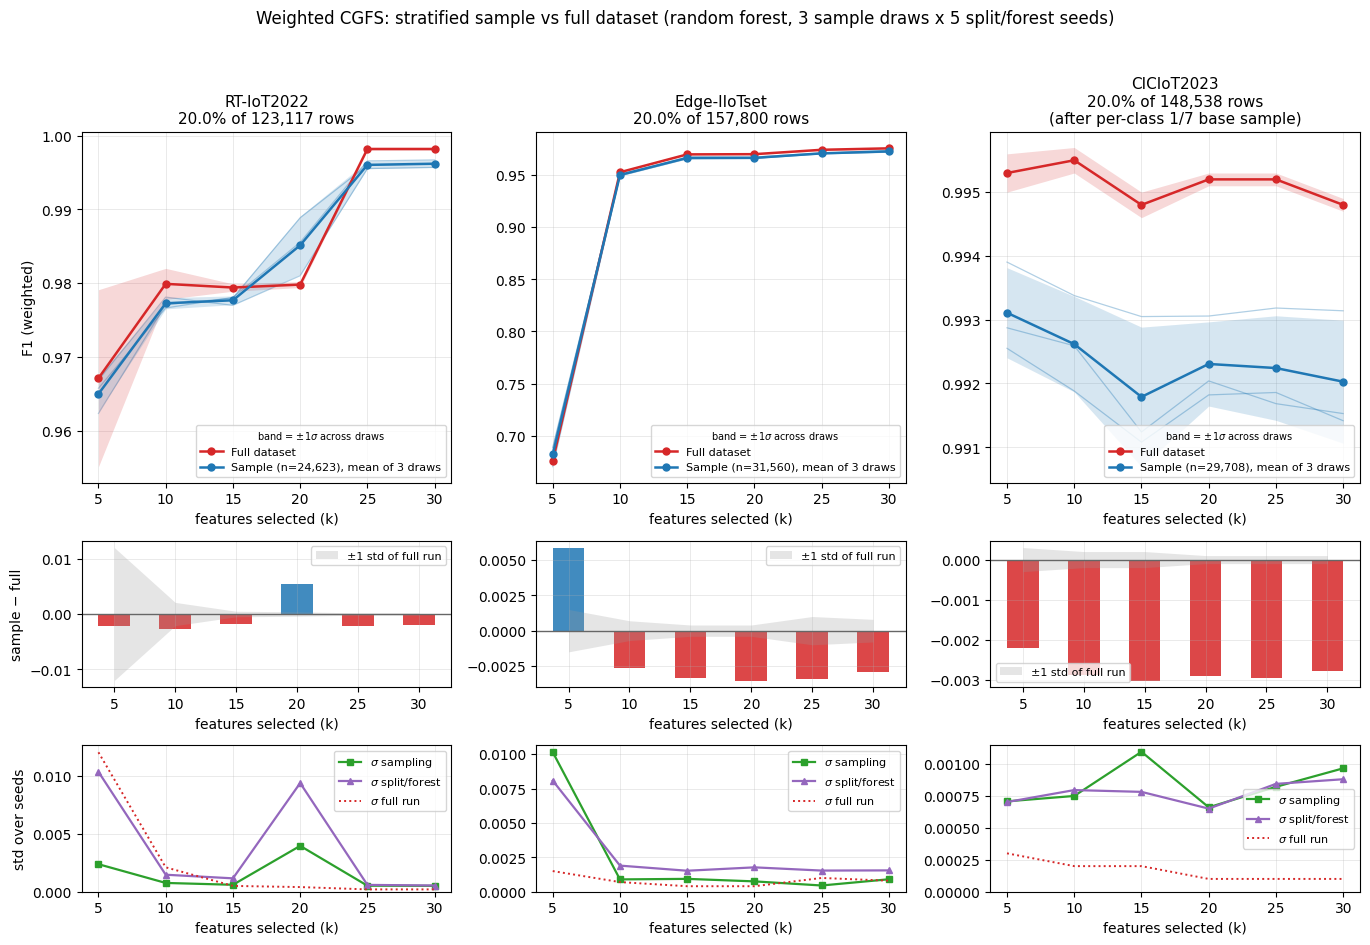

In [32]:
n = len(keys)
if n == 0:
    print("nothing to plot -- no dataset ran")
else:
    fig, axes = plt.subplots(3, n, figsize=(4.6 * n, 9.6), squeeze=False,
                             gridspec_kw={"height_ratios": [2.4, 1, 1]})
    C_SAMP, C_FULL = "#1f77b4", "#d62728"

    for j, key in enumerate(keys):
        b = cmp[cmp.dataset == key].sort_values("k")
        ks = b["k"].to_numpy()
        ax = axes[0][j]

        # Individual sample draws, so the reader can see the scatter the band
        # is summarising rather than take it on trust.
        pd_b = per_draw[per_draw.dataset == key]
        for ss, gsub in pd_b.groupby("sample_seed"):
            gsub = gsub.sort_values("k")
            ax.plot(gsub["k"], gsub["draw_mean"], "-", color=C_SAMP,
                    alpha=0.35, lw=0.9, zorder=1)

        for mu, sd, c, lab in ((b["full_mean"], b["full_std"], C_FULL, "Full dataset"),
                               (b["samp_mean"], b["std_sampling"], C_SAMP, None)):
            mu, sd = mu.to_numpy(), np.nan_to_num(sd.to_numpy())
            if lab is None:
                n_s = meta[key]["n_sample"]
                lab = (f"Sample (n={n_s:,}), mean of {len(SAMPLE_SEEDS)} draws"
                       if n_s else "Full (re-run)")
            ax.plot(ks, mu, "o-", color=c, label=lab, lw=1.8, ms=5, zorder=3)
            ax.fill_between(ks, mu - sd, mu + sd, color=c, alpha=0.18, lw=0, zorder=2)

        n_s, n_f = meta[key]["n_sample"], meta[key]["n_full"]
        base = meta[key]["base"]
        sub = f"{n_s / n_f:.1%} of {n_f:,} rows" if n_s else f"{n_f:,} rows"
        if base:
            sub += f"\n(after per-class 1/{round(1 / base['frac'])} base sample)"
        ax.set_title(f"{meta[key]['name']}\n{sub}", fontsize=11)
        ax.set_xlabel("features selected (k)")
        if j == 0:
            ax.set_ylabel(f"F1 ({F1_AVERAGE})")
        ax.set_xticks(ks)
        ax.grid(alpha=0.3, lw=0.6)
        ax.legend(fontsize=8, loc="lower right",
                  title=r"band = $\pm1\sigma$ across draws", title_fontsize=7)

        # Difference panel.
        axd = axes[1][j]
        delta = b["delta"].to_numpy()
        axd.axhline(0, color="0.4", lw=1)
        axd.bar(ks, delta, width=2.6,
                color=np.where(delta >= 0, C_SAMP, C_FULL), alpha=0.85)
        # The full run's own seed-to-seed spread: inside this band, the sample is
        # not distinguishable from the full dataset.
        fs = np.nan_to_num(b["full_std"].to_numpy())
        axd.fill_between(ks, -fs, fs, color="0.6", alpha=0.25, lw=0,
                         label="±1 std of full run")
        axd.set_xlabel("features selected (k)")
        if j == 0:
            axd.set_ylabel("sample − full")
        axd.set_xticks(ks)
        axd.grid(alpha=0.3, lw=0.6)
        axd.legend(fontsize=8)

        # Variance decomposition: which seed dimension actually moves the result.
        axv = axes[2][j]
        axv.plot(ks, np.nan_to_num(b["std_sampling"].to_numpy()), "s-",
                 color="#2ca02c", lw=1.6, ms=4, label=r"$\sigma$ sampling")
        axv.plot(ks, b["std_split"].to_numpy(), "^-", color="#9467bd",
                 lw=1.6, ms=4, label=r"$\sigma$ split/forest")
        axv.plot(ks, np.nan_to_num(b["full_std"].to_numpy()), ":", color=C_FULL,
                 lw=1.4, label=r"$\sigma$ full run")
        axv.set_xlabel("features selected (k)")
        if j == 0:
            axv.set_ylabel("std over seeds")
        axv.set_xticks(ks)
        axv.set_ylim(bottom=0)
        axv.grid(alpha=0.3, lw=0.6)
        axv.legend(fontsize=8)

    fig.suptitle("Weighted CGFS: stratified sample vs full dataset (random forest, "
                 f"{len(SAMPLE_SEEDS)} sample draws x {len(SEEDS)} split/forest seeds)",
                 fontsize=12)
    fig.tight_layout(rect=(0, 0, 1, 0.96))

    os.makedirs(OUT_DIR, exist_ok=True)
    for ext in ("png", "pdf"):
        p = os.path.join(OUT_DIR, f"cgfs_sample_vs_full.{ext}")
        fig.savefig(p, dpi=300, bbox_inches="tight")
        print("wrote", p)
    plt.show()

## 12. Save

In [33]:
os.makedirs(OUT_DIR, exist_ok=True)
p_raw = os.path.join(OUT_DIR, "cgfs_sample_raw.csv")
p_cmp = os.path.join(OUT_DIR, "cgfs_sample_vs_full.csv")
sample.to_csv(p_raw, index=False)          # one row per (sample_seed, seed, k)
cmp.to_csv(p_cmp, index=False)
p_draw = os.path.join(OUT_DIR, "cgfs_sample_per_draw.csv")
per_draw.to_csv(p_draw, index=False)       # collapsed to one row per draw
print("wrote", p_draw)
print("wrote", p_raw)
print("wrote", p_cmp)

# Paste-ready LaTeX of the comparison.
lines = ["% Weighted CGFS: stratified sample vs full dataset.",
         "% Requires \\usepackage{booktabs}."]
for key in keys:
    b = cmp[cmp.dataset == key].sort_values("k")
    n_s, n_f = meta[key]["n_sample"], meta[key]["n_full"]
    cap = (f"{meta[key]['name']}: weighted CGFS F1 ({F1_AVERAGE}) on a stratified "
           f"sample of {n_s:,} rows ({n_s / n_f:.1%}) against the full dataset. "
           f"Sample row: mean $\\pm$ std across {len(SAMPLE_SEEDS)} independent draws, "
           f"each averaged over {len(SEEDS)} split/forest seeds; "
           f"$\\sigma_{{\\mathrm{{split}}}}$ is the within-draw spread."
           ) if n_s else meta[key]["name"]
    lines += ["\\begin{table}[t]\\centering\\small",
              f"\\caption{{{cap}}}", f"\\label{{tab:sample-{key}}}",
              "\\begin{tabular}{lcccccc}", "\\toprule",
              "$k$ & " + " & ".join(str(int(k)) for k in b["k"]) + " \\\\", "\\midrule",
              "Sample & " + " & ".join(f"{m:.4f} $\\pm$ {s:.4f}"
                                       for m, s in zip(b["samp_mean"], np.nan_to_num(b["std_sampling"]))) + " \\\\",
              "$\\sigma_{\\mathrm{split}}$ & " + " & ".join(f"{s:.4f}" for s in b["std_split"]) + " \\\\",
              "Full & " + " & ".join(f"{m:.4f} $\\pm$ {s:.4f}"
                                     for m, s in zip(b["full_mean"], b["full_std"])) + " \\\\",
              "$\\Delta$ & " + " & ".join(f"{d:+.4f}" for d in b["delta"]) + " \\\\",
              "\\bottomrule", "\\end{tabular}", "\\end{table}", ""]
p_tex = os.path.join(OUT_DIR, "cgfs_sample_vs_full.tex")
open(p_tex, "w").write("\n".join(lines))
print("wrote", p_tex)

wrote ./cgfs_sample_per_draw.csv
wrote ./cgfs_sample_raw.csv
wrote ./cgfs_sample_vs_full.csv
wrote ./cgfs_sample_vs_full.tex
